# 00 The charts

DATA 5500 — Sara Choque Molina

This notebook builds the figures used in the project reports, straight from the CSV files
that came out of BigQuery. Running it from top to bottom rebuilds every picture, so the
charts can always be traced back to the data instead of being drawn by hand.

The numbers printed under each chart are the ones quoted in the written reports.

## Block 1 — Setup

Everything is plain matplotlib. Colors come from **viridis**, which is the colormap I use for
all my work: it stays readable when printed in black and white and it works for the most
common kinds of color blindness.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FOLDER = r"C:\Users\sara_\Desktop\College\DATA 5500-01 Senior Des\data bases"

# Where the finished pictures get saved
FIGURES = os.path.join(FOLDER, "figures")
os.makedirs(FIGURES, exist_ok=True)

print("Folder found:", os.path.isdir(FOLDER))

Folder found: True


## Block 2 — Load a daily count file

All of the daily files have the same shape, so one small function reads any of them.

In [5]:
def load_daily(filename):
    """Read one of the daily count files and give back a tidy table."""
    df = pd.read_csv(os.path.join(FOLDER, filename))

    # BigQuery gives the day as a number like 20211217. Turning it into a real
    # date makes the charts space the days out correctly.
    df["day"] = pd.to_datetime(df["day"].astype(str), format="%Y%m%d")
    return df.sort_values("day")

clowns = load_daily("09_daily_total_2016_clowns.csv")

print("Days:", len(clowns))
clowns.head()

Days: 75


,day,articles
0,2016-09-01,49
1,2016-09-02,71
2,2016-09-03,55
3,2016-09-04,56
4,2016-09-05,43


## Block 3 — Figure 1: one period on its own

The thin gray line is the real count for each day. Weekends are always low and weekdays are
always high, which makes the raw line jump around a lot, so the black line is a 7-day average
that shows the shape of the trend underneath that weekly pattern.

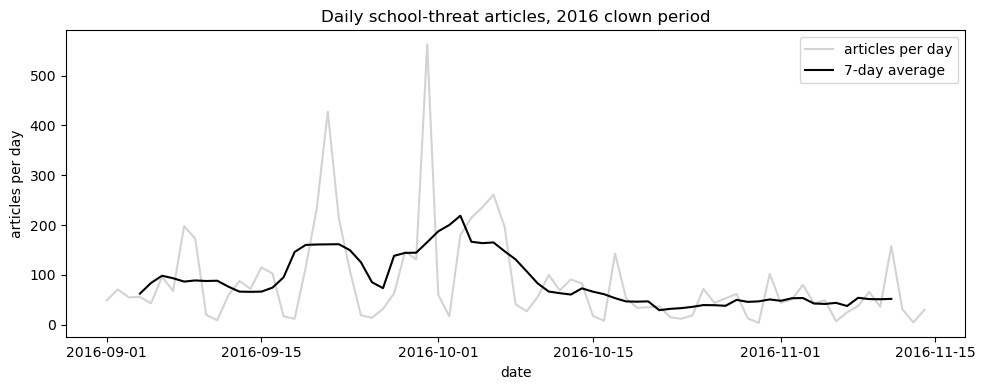

Busiest day: 2016-09-30 with 563 articles


In [6]:
# Schools are closed on weekends, so the raw daily count drops every Saturday and Sunday. 
# That weekly pattern is not part of the trend; it just hides it,
# So I smooth it out with a 7-day average before looking at the shape

# center=True puts the result in the middle day instead of the last one, 
#so the smooth line sits on top of the spikes instead of lagging behind them
clowns["avg7"] = clowns["articles"].rolling(7, center=True).mean()

plt.figure(figsize=(10, 4))
# Both lines are plotted so the smoothing is visible instead of hidden
plt.plot(clowns["day"], clowns["articles"], color="lightgray", label="articles per day")
plt.plot(clowns["day"], clowns["avg7"], color="black", label="7-day average")

plt.title("Daily school-threat articles, 2016 clown period")
plt.xlabel("date")
plt.ylabel("articles per day")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "fig1_clowns_2016.png"), dpi=150)
plt.show()

# idxmax gives the position of the largest value, not the value itself, so .loc
# can pull the whole row and I get the date and the count together.
peak = clowns.loc[clowns["articles"].idxmax()]
print("Busiest day:", peak["day"].date(), "with", peak["articles"], "articles")

The gray line is the real count for each day. Schools are closed on weekends, so the raw count drops every Saturday and Sunday and that weekly pattern hides the shape of the trend. The black line is a 7-day average, which cancels the weekend effect out. Both are shown so the smoothing is visible rather than hidden.

## Block 4 — Figure 2: what the count is actually made of

This is the most important chart in the project.

The query asks for articles about school threats, but it also catches articles about threats
against school board members, pandemic lockdowns and real shootings. This chart splits each
day into those categories so the problem is visible inside one total.

The printed percentages underneath are what the reports quote as the noise level.

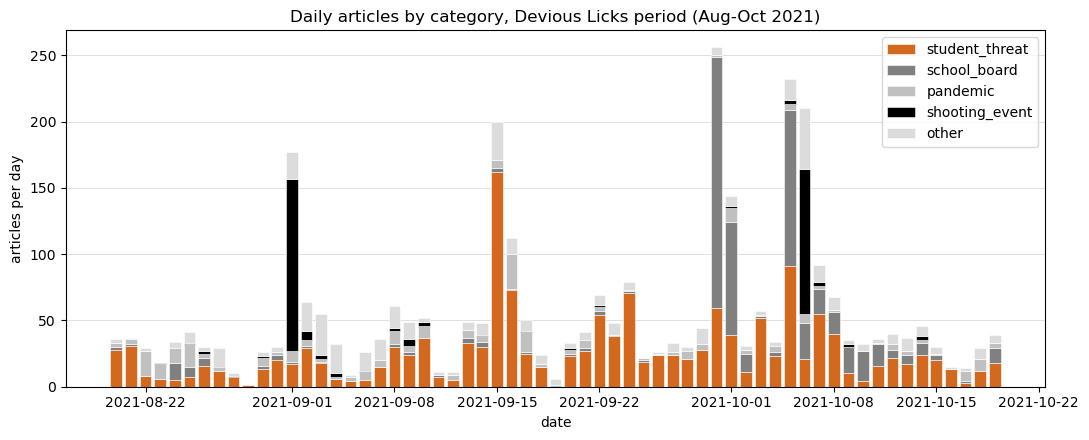

category
student_threat    47.6
school_board      19.4
pandemic           8.9
shooting_event     8.7
other             15.4


In [22]:
cats = load_daily("04_daily_categories_2021_deviouslicks.csv")

# One row per day with the categories as columns, which is what a stacked bar needs.
wide = cats.pivot(index="day", columns="category", values="articles").fillna(0).astype(int)

order = ["student_threat", "school_board", "pandemic", "shooting_event", "other"]
wide = wide[[c for c in order if c in wide.columns]]
colors = ["chocolate", "gray", "silver", "black", "gainsboro"]
plt.figure(figsize=(11, 4.5))

# bottom is where each layer starts, so the next one sits on top of it.
bottom = np.zeros(len(wide))
for color, column in zip(colors, wide.columns):
    plt.bar(wide.index, wide[column], bottom=bottom, color=color, label=column,
            width=0.8, edgecolor="white", linewidth=0.4)
    bottom = bottom + wide[column].values

plt.grid(axis="y", color="lightgray", linewidth=0.5)
plt.gca().set_axisbelow(True)

plt.title("Daily articles by category, Devious Licks period (Aug-Oct 2021)")
plt.xlabel("date")
plt.ylabel("articles per day")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "fig2_deviouslicks_categories.png"), dpi=150)
plt.show()

share = wide.sum() / wide.sum().sum() * 100
print(share.round(1).to_string())

## Block 5 — Figure 3: all five periods side by side

The five periods have very different sizes, so the raw counts cannot be compared directly. Each period is divided by its own normal level first, which is baseline normalization, a standard way of handling this in time series work. The normal level is the median of the first third of the period, taken before the trend starts, and the median is used instead of the mean so that a single busy day does not inflate it.

The dashed line at 2 is the alert level. That number is my choice rather than a standard, so the table reports the same count at 1.5, 2 and 3. If the threat periods stay above the line and the control periods stay below it at all three, the conclusion does not depend on the threshold I picked.

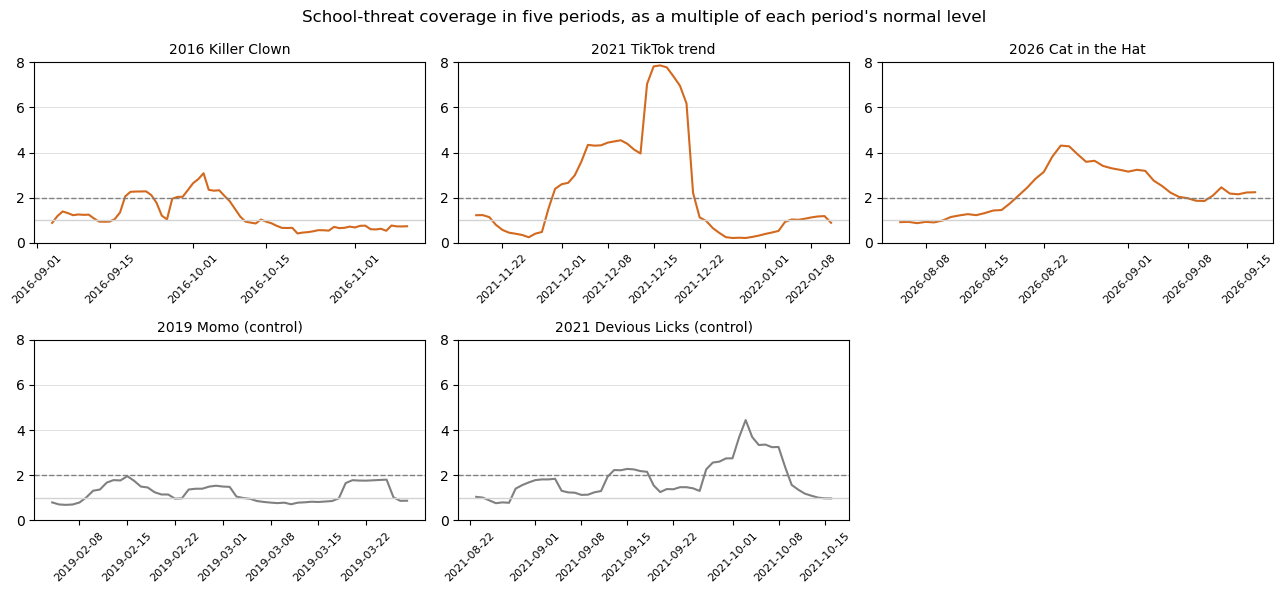

,peak,days above 1.5x,days above 2x,days above 3x
period,,,,
2016 Killer Clown,3.1,20,16,1
2021 TikTok trend,7.9,23,22,17
2026 Cat in the Hat,4.3,30,26,13
2019 Momo (control),2.0,13,0,0
2021 Devious Licks (control),4.4,28,19,7


In [27]:
periods = [
    ("2016 Killer Clown", "09_daily_total_2016_clowns.csv", "chocolate"),
    ("2021 TikTok trend", "12_daily_total_2021_tiktok.csv", "chocolate"),
    ("2026 Cat in the Hat", "13_daily_total_2026_cathat.csv", "chocolate"),
    ("2019 Momo (control)", "10_daily_total_2019_momo.csv", "gray"),
    ("2021 Devious Licks (control)", "11_daily_total_2021_deviouslicks.csv", "gray"),
]

thresholds = [1.5, 2, 3]
results = []

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.flatten()

for ax, (name, filename, color) in zip(axes, periods):
    d = load_daily(filename)
    d["avg7"] = d["articles"].rolling(7, center=True).mean()

    # Baseline normalization. Median of the first third, which is before the trend
    # starts, and the median ignores single-day spikes that would inflate a mean.
    normal = d["articles"][: len(d) // 3].median()
    d["times_normal"] = d["avg7"] / normal

    ax.plot(d["day"], d["times_normal"], color=color)
    ax.axhline(1, color="lightgray", linewidth=1)
    ax.axhline(2, color="gray", linestyle="--", linewidth=1)
    ax.set_ylim(0, 8)
    ax.set_title(name, fontsize=10)
    ax.grid(axis="y", color="lightgray", linewidth=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)

    row = {"period": name, "peak": round(d["times_normal"].max(), 1)}
    for t in thresholds:
        row[f"days above {t}x"] = int((d["times_normal"] > t).sum())
    results.append(row)

axes[-1].axis("off")

fig.suptitle("School-threat coverage in five periods, as a multiple of each period's normal level")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES, "fig3_five_periods.png"), dpi=150)
plt.show()

pd.DataFrame(results).set_index("period")

All three threat periods rise well above their normal level. The 2021 TikTok trend is the largest at 7.9 times normal, followed by Cat in the Hat at 4.3 and the 2016 clown panic at 3.1. The clown panic is weaker than I expected, which is worth noting because it is often described as the largest of the three.

Momo behaves the way a control should. It peaks at exactly 2.0 and spends no days above the alert line, so a viral panic with no school threats attached does not set this measure off.

Devious Licks does not. It peaks at 4.4, higher than the clown panic, and spends 19 days above the line. On the raw counts, a trend that produced no threats looks like one that did.

The category chart explains why. Only 47.6% of the Devious Licks articles are about student threats. The rest are school board coverage, real shootings and pandemic closures, and that is enough volume to push the measure over the line on its own. The spike is real, but it is not a threat spike.

This sets up the test the rest of the project has to pass. Once the classifier has removed the coverage that is not about student threats, Devious Licks should fall below the alert line while the three threat periods stay above it. If that happens, the classification step is doing the work it is supposed to do.

One limit of the threshold check: the separation holds at 2 and at 3, but not at 1.5, where Momo also spends 13 days above the line. The alert level cannot be set much lower than 2 without losing the controls.

## Still to add

The "after cleaning" chart, which drops the non-student-threat categories and lines the
periods up on their peak day, goes here once the labeling is done.